In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# load the data and display the first few rows
df = pd.read_csv('../../data/train-test.csv')
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
# describe the dataset to get a summary of statistics for each column
df.describe()


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [4]:
# get information about the dataset, including the number of non-null values and data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


we found 300 values null in weight col and 374 values null in market index


we will handle them by filling it with the mean of each col

In [5]:
# select only the float64 columns from the dataframe to fill the null values with the mean of each column
df_float = df.select_dtypes(include=['float64'])
df_float.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pickup_lat    48000 non-null  float64
 1   pickup_lon    48000 non-null  float64
 2   delivery_lat  48000 non-null  float64
 3   delivery_lon  48000 non-null  float64
 4   distance      48000 non-null  float64
 5   weight        47700 non-null  float64
 6   market_index  47626 non-null  float64
 7   quote_signal  48000 non-null  float64
 8   posted_rate   48000 non-null  float64
dtypes: float64(9)
memory usage: 3.3 MB


In [6]:
float_cols = df_float.columns
df[float_cols] = df_float.fillna(df_float.mean())

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        48000 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  48000 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [8]:
df.sum().isnull()

load_id         False
pickup          False
delivery        False
pickup_lat      False
pickup_lon      False
delivery_lat    False
delivery_lon    False
distance        False
equipment       False
weight          False
date            False
market_index    False
quote_signal    False
posted_rate     False
dtype: bool

In [9]:
df.describe(include='all')

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
count,48000,48000,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,48000.000000,48000,48000.000000,48000.000000,48000.000000
unique,48000,64,64,NaN,NaN,NaN,NaN,NaN,3,NaN,304,NaN,NaN,NaN
top,TR-000001,Oklahoma City,Lexington,NaN,NaN,NaN,NaN,NaN,Dry Van,NaN,2025-06-17,NaN,NaN,NaN
freq,1,1242,1197,NaN,NaN,NaN,NaN,NaN,27202,NaN,198,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.647545,-90.928964,35.641175,-90.857310,1135.856654,NaN,31028.844004,NaN,1.083387,2.062468,2373.980682
std,NaN,NaN,NaN,4.315285,13.482431,4.317199,13.476589,728.564416,NaN,9362.045754,NaN,0.167435,0.291391,1486.493245
min,NaN,NaN,NaN,28.357650,-121.698490,28.357650,-121.698490,70.000000,NaN,-47500.000000,NaN,0.676390,0.692280,57.220000
25%,NaN,NaN,NaN,31.986910,-98.400590,31.986910,-98.400590,550.400000,NaN,25835.750000,NaN,0.950610,1.891030,1251.555000
50%,NaN,NaN,NaN,35.294790,-88.089150,35.294790,-87.528710,953.300000,NaN,31367.000000,NaN,1.057625,2.055750,2030.760000
75%,NaN,NaN,NaN,39.411040,-83.285060,39.411040,-83.285060,1645.525000,NaN,36985.000000,NaN,1.218525,2.221685,3330.750000


by filling the null values with null we see there is no difference in the statistics of each feature

In [10]:
# Display all duplicate rows
df[df.duplicated()]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate


No duplicate values

In [11]:
df["date"] = pd.to_datetime(df["date"])

# 2. Extract Standard Tabular Features (Great for XGBoost / Random Forest)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
df["day_of_year"] = df["date"].dt.dayofyear
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# 3. Extract Cyclical Encodings (Great for Neural Networks / Linear Models)
# Encode Month (T = 12)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Encode Day of Week (T = 7)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Encode Day of Year (T = 365)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# View a selection of the newly generated features
print(
    df[
        [
            "load_id",
            "date",
            "day_of_week",
            "is_weekend",
            "month_sin",
            "month_cos",
        ]
    ]
)

         load_id       date  day_of_week  is_weekend  month_sin  month_cos
0      TR-000001 2025-01-01            2           0   0.500000   0.866025
1      TR-000002 2025-01-01            2           0   0.500000   0.866025
2      TR-000003 2025-01-01            2           0   0.500000   0.866025
3      TR-000004 2025-01-01            2           0   0.500000   0.866025
4      TR-000005 2025-01-01            2           0   0.500000   0.866025
...          ...        ...          ...         ...        ...        ...
47995  TR-047996 2025-10-31            4           0  -0.866025   0.500000
47996  TR-047997 2025-10-31            4           0  -0.866025   0.500000
47997  TR-047998 2025-10-31            4           0  -0.866025   0.500000
47998  TR-047999 2025-10-31            4           0  -0.866025   0.500000
47999  TR-048000 2025-10-31            4           0  -0.866025   0.500000

[48000 rows x 6 columns]


In [12]:
df_copy = df.copy()

In [13]:
# convert categorical columns to numerical using one-hot encoding
df = pd.get_dummies(df, columns=["pickup", "delivery", "equipment"], drop_first=True, dtype=int)


In [14]:
df.head()

,load_id,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,...,delivery_Shreveport,delivery_St. Louis,delivery_Syracuse,delivery_Tampa,delivery_Toledo,delivery_Tucson,delivery_Tulsa,delivery_Washington,equipment_Flatbed,equipment_Reefer
0,TR-000001,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,...,0,0,0,0,0,0,0,0,0,0
1,TR-000002,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,...,0,0,0,0,0,0,0,0,0,1
2,TR-000003,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,...,0,0,0,0,0,0,0,0,0,0
3,TR-000004,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,...,0,0,0,0,0,0,0,0,0,0
4,TR-000005,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,...,0,0,0,0,0,0,0,0,0,1


In [15]:
columns_to_drop = ["load_id", "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos", "year"]
df.drop(columns=columns_to_drop, inplace=True)
df_copy.drop(columns=columns_to_drop, inplace=True)

In [16]:
# Create new features for the DataFrame.
# Negative freight weights are invalid. 233 of 38,242 training weights are negative.
df["weight_clean"] = df["weight"].abs()

df["weight_per_mile"] = df["weight_clean"] / df["distance"]
df["lat_difference"] = df["delivery_lat"] - df["pickup_lat"]
df["lon_difference"] = df["delivery_lon"] - df["pickup_lon"]
df["abs_lat_difference"] = df["lat_difference"].abs()
df["abs_lon_difference"] = df["lon_difference"].abs()

df_copy["weight_clean"] = df_copy["weight"].abs()
df_copy["weight_per_mile"] = df_copy["weight_clean"] / df_copy["distance"]
df_copy["lat_difference"] = df_copy["delivery_lat"] - df_copy["pickup_lat"]
df_copy["lon_difference"] = df_copy["delivery_lon"] - df_copy["pickup_lon"]
df_copy["abs_lat_difference"] = df_copy["lat_difference"].abs()
df_copy["abs_lon_difference"] = df_copy["lon_difference"].abs()


In [17]:
df["date"] = pd.to_datetime(df["date"])

train_df = df[df["date"] < "2025-09-01"].copy()

X_train = train_df.drop(columns=["posted_rate", "date"])
y_train = train_df["posted_rate"]

valid_df = df[
    (df["date"] >= "2025-09-01") &
    (df["date"] < "2025-10-01")
].copy()
valid_df = valid_df.drop(columns=["date"])

test_df = df[
    (df["date"] >= "2025-10-01") &
    (df["date"] < "2025-11-01")
].copy()
X_test = test_df.drop(columns=["posted_rate", "date"])
y_test = test_df["posted_rate"]

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)


(38477, 150)
(4670, 149)
(4853, 150)


In [18]:
df.head()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,...,delivery_Tulsa,delivery_Washington,equipment_Flatbed,equipment_Reefer,weight_clean,weight_per_mile,lat_difference,lon_difference,abs_lat_difference,abs_lon_difference
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,645.41,...,0,0,0,0,30658.0,111.768137,0.07786,4.04342,0.07786,4.04342
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,679.97,...,0,0,0,1,17555.0,62.584670,1.13195,3.82196,1.13195,3.82196
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,1802.54,...,0,0,0,0,31721.0,32.776400,5.07979,-14.56161,5.07979,14.56161
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,1827.28,...,0,0,0,0,32333.0,33.491817,-4.70395,-14.10889,4.70395,14.10889
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,1380.28,...,0,0,0,1,35183.0,64.925263,3.46454,6.29428,3.46454,6.29428


In [19]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel

# X_train, y_train, X_valid, X_test must already exist
# Ensure posted_rate and load_id are not inside X_*

selector_model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

selector = SelectFromModel(
    estimator=selector_model,
    threshold="median"   # keeps approximately the top 50% by importance
)

# Learn important features from training data only
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()].tolist()

print("Original features:", X_train.shape[1])
print("Selected features:", len(selected_features))
print(selected_features)

Original features: 148
Selected features: 74
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'month', 'day', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend', 'pickup_Atlanta', 'pickup_Bakersfield', 'pickup_Baton Rouge', 'pickup_Boston', 'pickup_Buffalo', 'pickup_Charleston', 'pickup_Dallas', 'pickup_El Paso', 'pickup_Fort Wayne', 'pickup_Grand Rapids', 'pickup_Green Bay', 'pickup_Greensboro', 'pickup_Hartford', 'pickup_Lexington', 'pickup_Los Angeles', 'pickup_Mobile', 'pickup_Montgomery', 'pickup_Nashville', 'pickup_Phoenix', 'pickup_Reno', 'pickup_Richmond', 'pickup_Tucson', 'pickup_Washington', 'delivery_Atlanta', 'delivery_Bakersfield', 'delivery_Baltimore', 'delivery_Baton Rouge', 'delivery_Boston', 'delivery_Buffalo', 'delivery_Charleston', 'delivery_Cincinnati', 'delivery_Fort Wayne', 'delivery_Fresno', 'delivery_Harrisburg', 'delivery_Hartford', 'delivery_Jacksonville', 'delivery_Little Rock', 'delivery_Lu

In [20]:
# Separate validation features and target
X_valid = valid_df.drop(columns=["posted_rate"])
y_valid = valid_df["posted_rate"]

# Keep only the features selected from the training set
X_train_selected = X_train[selected_features]
X_valid_selected = X_valid[selected_features]

assert len(X_train_selected) == len(y_train)
assert len(X_valid_selected) == len(y_valid)
assert list(X_train_selected.columns) == list(X_valid_selected.columns)

In [21]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model = ExtraTreesRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_selected, y_train)

valid_predictions = model.predict(X_valid_selected)

print("Validation MAE:", mean_absolute_error(y_valid, valid_predictions))
print("Validation RMSE:", root_mean_squared_error(y_valid, valid_predictions))
print("Validation R²:", r2_score(y_valid, valid_predictions))


Validation MAE: 145.96045977858677
Validation RMSE: 655.2829580489274
Validation R²: 0.8149560168754449


In [22]:
results = pd.DataFrame({
    "actual": y_valid,
    "predicted": valid_predictions
})

results["absolute_error"] = (results["actual"] - results["predicted"]).abs()

results.sort_values("absolute_error", ascending=False).head(10)

,actual,predicted,absolute_error
40096,20132.37,3815.196003,16317.173997
40171,20361.89,4747.420733,15614.469267
40322,14949.25,3237.894267,11711.355733
42881,13503.63,2857.450703,10646.179297
42149,13026.22,2816.197405,10210.022595
42735,12797.54,3563.690567,9233.849433
39362,11684.70,2884.296023,8800.403977
40158,12240.81,3738.576578,8502.233422
38771,11377.49,3469.367733,7908.122267
42645,13420.59,5639.702105,7780.887895


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Keep rows aligned with the prediction array
viz = valid_df[
    [
        "pickup_lat", "pickup_lon",
        "delivery_lat", "delivery_lon",
        "distance", "posted_rate"
    ]
].copy().reset_index(drop=True)

viz["predicted_rate"] = np.asarray(valid_predictions)
viz["residual"] = viz["posted_rate"] - viz["predicted_rate"]

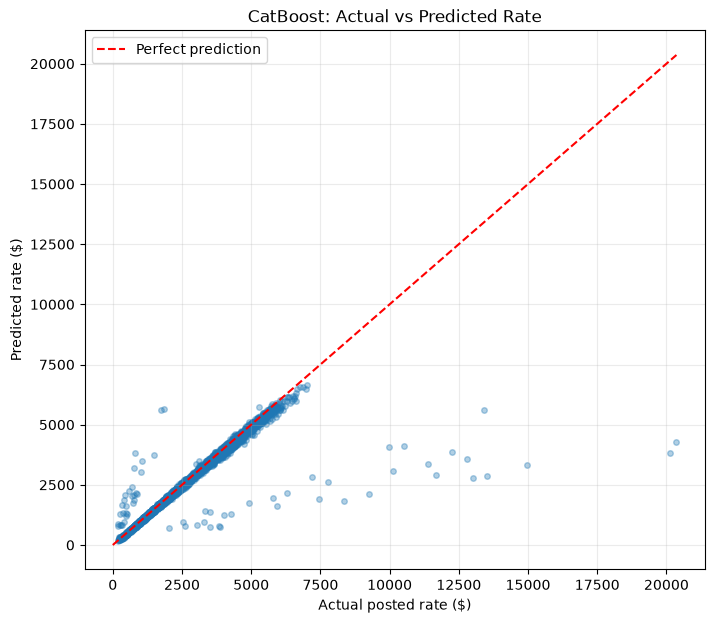

In [35]:
plt.figure(figsize=(8, 7))

plt.scatter(
    viz["posted_rate"],
    viz["predicted_rate"],
    alpha=0.35,
    s=16
)

max_rate = max(viz["posted_rate"].max(), viz["predicted_rate"].max())

# Perfect prediction line
plt.plot([0, max_rate], [0, max_rate], "r--", label="Perfect prediction")

plt.xlabel("Actual posted rate ($)")
plt.ylabel("Predicted rate ($)")
plt.title("CatBoost: Actual vs Predicted Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

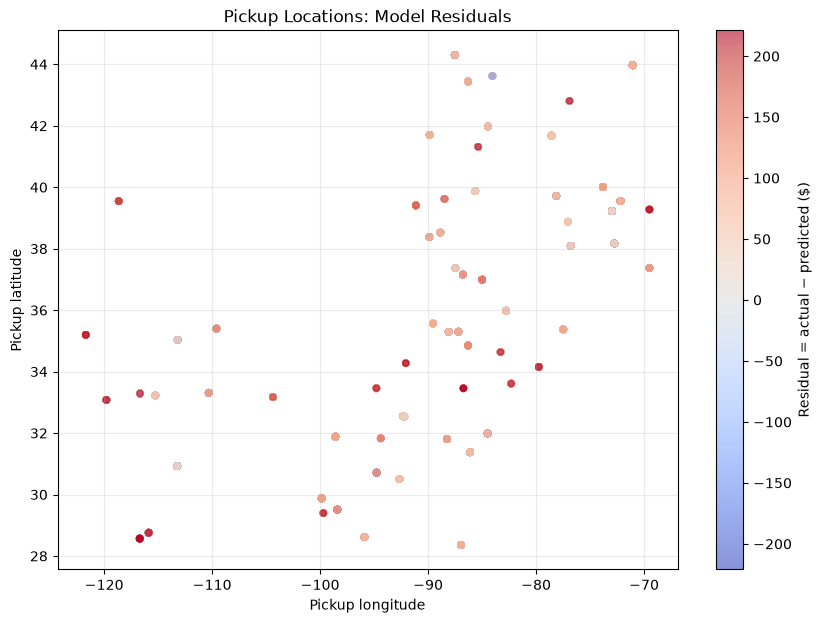

In [36]:
limit = np.quantile(np.abs(viz["residual"]), 0.95)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    viz["pickup_lon"],
    viz["pickup_lat"],
    c=viz["residual"],
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label="Residual = actual − predicted ($)")
plt.xlabel("Pickup longitude")
plt.ylabel("Pickup latitude")
plt.title("Pickup Locations: Model Residuals")
plt.grid(alpha=0.25)
plt.show()

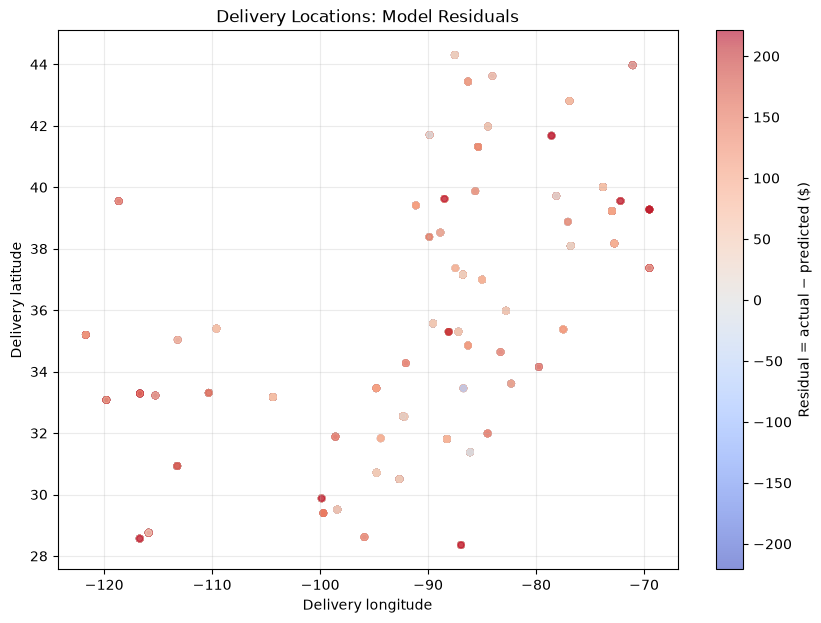

In [37]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    viz["delivery_lon"],
    viz["delivery_lat"],
    c=viz["residual"],
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label="Residual = actual − predicted ($)")
plt.xlabel("Delivery longitude")
plt.ylabel("Delivery latitude")
plt.title("Delivery Locations: Model Residuals")
plt.grid(alpha=0.25)
plt.show()

In [23]:
df["date"] = pd.to_datetime(df["date"])

train_copy_df = df_copy[df_copy["date"] < "2025-09-01"].copy()

X_copy_train = train_copy_df.drop(columns=["posted_rate", "date"])
y_copy_train = train_copy_df["posted_rate"]

valid_copy_df = df_copy[
    (df_copy["date"] >= "2025-09-01") &
    (df_copy["date"] < "2025-10-01")
].copy()
X_copy_valid = valid_copy_df.drop(columns=["date", "posted_rate"])
y_copy_valid = valid_copy_df["posted_rate"]


test_copy_df = df_copy[
    (df_copy["date"] >= "2025-10-01") &
    (df_copy["date"] < "2025-11-01")
].copy()


X_copy_test = test_copy_df.drop(columns=["posted_rate", "date"])
y_copy_test = test_copy_df["posted_rate"]

print(train_copy_df.shape)
print(valid_copy_df.shape)
print(test_copy_df.shape)


(38477, 25)
(4670, 25)
(4853, 25)


In [24]:
X_copy_train.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,...,day_of_week,day_of_year,quarter,is_weekend,weight_clean,weight_per_mile,lat_difference,lon_difference,abs_lat_difference,abs_lon_difference
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,...,2,1,1,0,30658.0,111.768137,0.07786,4.04342,0.07786,4.04342
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,...,2,1,1,0,17555.0,62.584670,1.13195,3.82196,1.13195,3.82196
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,...,2,1,1,0,31721.0,32.776400,5.07979,-14.56161,5.07979,14.56161
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,...,2,1,1,0,32333.0,33.491817,-4.70395,-14.10889,4.70395,14.10889
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,...,2,1,1,0,35183.0,64.925263,3.46454,6.29428,3.46454,6.29428


In [58]:
from catboost import CatBoostRegressor

cat_features = ["pickup", "delivery", "equipment"]

model = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.1,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_copy_train, y_copy_train,
    cat_features=cat_features,
    eval_set=(X_copy_valid, y_copy_valid),
    early_stopping_rounds=100
)

0:	learn: 1361.6715322	test: 1406.8876625	best: 1406.8876625 (0)	total: 40.1ms	remaining: 1m
100:	learn: 550.0619874	test: 619.7056613	best: 618.5260445 (59)	total: 3.96s	remaining: 54.9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 618.5260445
bestIteration = 59

Shrink model to first 60 iterations.


CatBoostRegressor(depth=8, iterations=1500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [59]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

valid_predictions = model.predict(X_copy_valid)

print("Validation MAE:", mean_absolute_error(y_copy_valid, valid_predictions))
print("Validation RMSE:", root_mean_squared_error(y_copy_valid, valid_predictions))
print("Validation R²:", r2_score(y_copy_valid, valid_predictions))

print("Best iteration:", model.get_best_iteration())

Validation MAE: 121.32894439184435
Validation RMSE: 618.5260491212871
Validation R²: 0.8351331992339274
Best iteration: 59


In [60]:
results = pd.DataFrame({
    "actual": y_copy_valid,
    "predicted": valid_predictions
})

results["absolute_error"] = (results["actual"] - results["predicted"]).abs()

results.sort_values("absolute_error", ascending=False).head(10)

,actual,predicted,absolute_error
40096,20132.37,3808.054619,16324.315381
40171,20361.89,4360.372978,16001.517022
40322,14949.25,3267.574766,11681.675234
42881,13503.63,2948.207509,10555.422491
42149,13026.22,2804.762822,10221.457178
42735,12797.54,3670.053784,9127.486216
39362,11684.70,2947.984602,8736.715398
40158,12240.81,3854.110182,8386.699818
42645,13420.59,5555.053310,7865.536690
38771,11377.49,3554.396098,7823.093902


In [61]:
import numpy as np
from sklearn.metrics import mean_absolute_error

y_val = y_copy_valid.reset_index(drop=True)
pred_val = np.asarray(valid_predictions)

tail_threshold = y_copy_train.quantile(0.99)

normal_mask = (y_val < tail_threshold).to_numpy()
tail_mask = (y_val >= tail_threshold).to_numpy()

print("Tail threshold:", tail_threshold)

print("Normal-row MAE:", mean_absolute_error(
    y_val[normal_mask],
    pred_val[normal_mask]
))

print("High-rate-row MAE:", mean_absolute_error(
    y_val[tail_mask],
    pred_val[tail_mask]
))

print("Number of high-rate validation rows:", tail_mask.sum())

Tail threshold: 5968.611199999998
Normal-row MAE: 85.65934645866938
High-rate-row MAE: 3417.19979341721
Number of high-rate validation rows: 50


In [62]:

from matplotlib.colors import TwoSlopeNorm

# Keep rows aligned with the prediction array
viz = valid_copy_df[
    [
        "pickup_lat", "pickup_lon",
        "delivery_lat", "delivery_lon",
        "distance", "posted_rate"
    ]
].copy().reset_index(drop=True)

viz["predicted_rate"] = np.asarray(valid_predictions)
viz["residual"] = viz["posted_rate"] - viz["predicted_rate"]

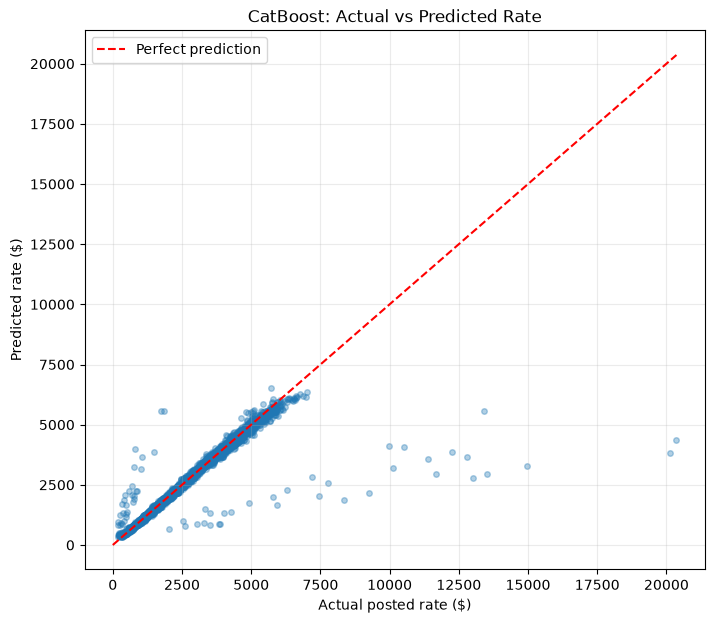

In [63]:
plt.figure(figsize=(8, 7))

plt.scatter(
    viz["posted_rate"],
    viz["predicted_rate"],
    alpha=0.35,
    s=16
)

max_rate = max(viz["posted_rate"].max(), viz["predicted_rate"].max())

# Perfect prediction line
plt.plot([0, max_rate], [0, max_rate], "r--", label="Perfect prediction")

plt.xlabel("Actual posted rate ($)")
plt.ylabel("Predicted rate ($)")
plt.title("CatBoost: Actual vs Predicted Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

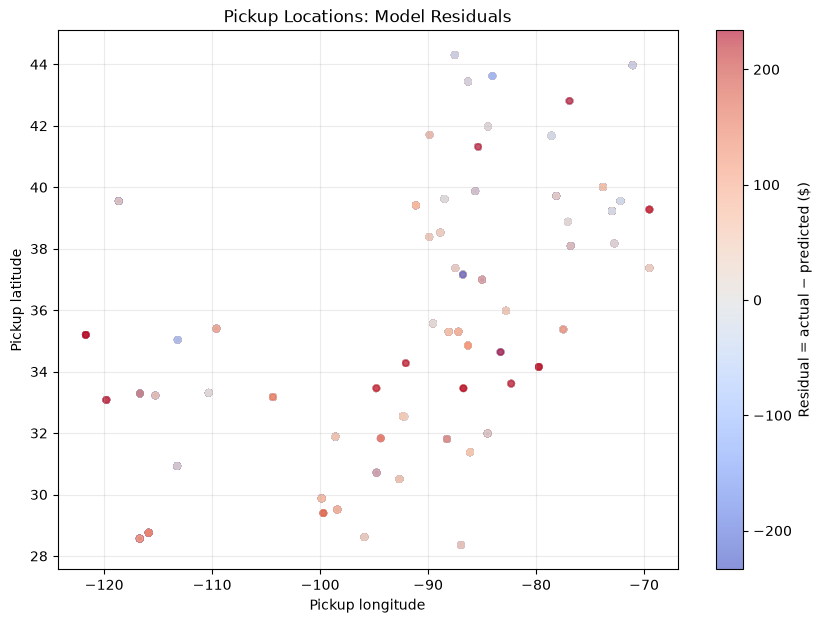

In [64]:
limit = np.quantile(np.abs(viz["residual"]), 0.95)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    viz["pickup_lon"],
    viz["pickup_lat"],
    c=viz["residual"],
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label="Residual = actual − predicted ($)")
plt.xlabel("Pickup longitude")
plt.ylabel("Pickup latitude")
plt.title("Pickup Locations: Model Residuals")
plt.grid(alpha=0.25)
plt.show()

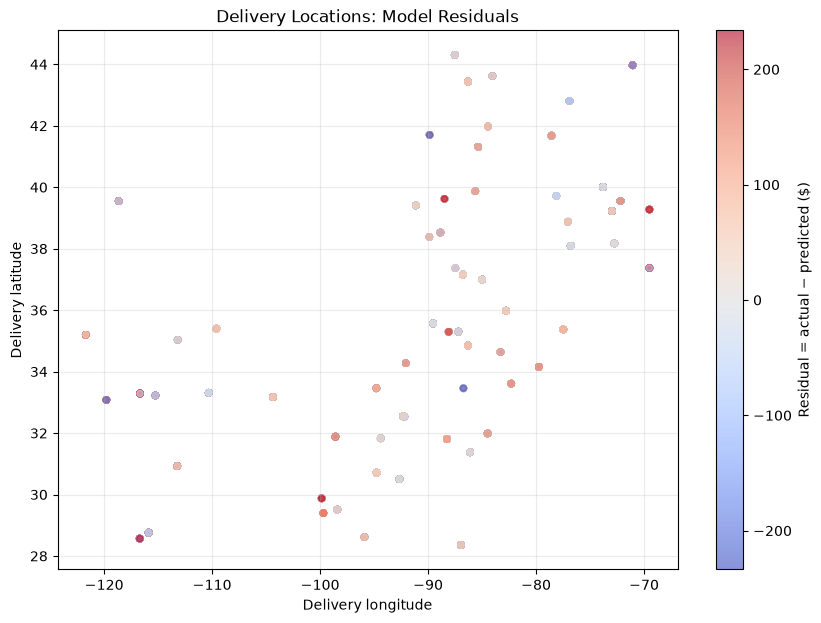

In [65]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    viz["delivery_lon"],
    viz["delivery_lat"],
    c=viz["residual"],
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label="Residual = actual − predicted ($)")
plt.xlabel("Delivery longitude")
plt.ylabel("Delivery latitude")
plt.title("Delivery Locations: Model Residuals")
plt.grid(alpha=0.25)
plt.show()

In [68]:
predicted = model.predict(X_copy_test)
results = pd.DataFrame({
    "actual": y_copy_test,
    "predicted": predicted
})

results["absolute_error"] = (results["actual"] - results["predicted"]).abs()

results.sort_values("absolute_error", ascending=True).head(50)

,actual,predicted,absolute_error
47757,2288.61,2288.658249,0.048249
44266,1441.53,1441.624129,0.094129
45448,1692.84,1692.935010,0.095010
45276,767.46,767.352061,0.107939
46514,2853.82,2853.930004,0.110004
43424,1414.03,1414.151749,0.121749
47045,1583.21,1583.062360,0.147640
47075,2165.46,2165.622339,0.162339
43762,1312.59,1312.760971,0.170971
46993,2232.43,2232.239098,0.190902
